
# LangGraph Reflection 机制开发指南

本指南详细介绍了如何在 **LangGraph** 中构建基于大语言模型（LLM）的 **Reflection（反思）** 机制。

Reflection 是一种重要的模型能力，通过让模型观察其过去的步骤和外部环境反馈，评估自身行为的质量，并不断改进输出。在生成与反思的循环中，模型可以逐步优化内容，从而提升生成质量和用户满意度。

Reflection 机制被广泛应用于生成任务中，例如文章写作、内容修改与反馈、以及智能助理等场景。通过引导 LLM 进行自我反思和用户反馈处理，开发者可以让模型在多轮交互中自动调整其生成的内容，达到高效、精准、结构完善的输出。



在本指南中，我们会逐步演示如何搭建这一机制，包括从基础的环境配置到生成器和反思器的构建，再到如何使用 LangGraph 状态图实现生成-反思循环的完整流程。无论您是为文章生成、内容评估，还是其他复杂任务设计 LLM 代理，本指南都将为您提供详细的开发思路和实用的代码示例。

![reflection](./images/reflection.png)

通过本指南，您将学习如何：
1. 设置开发环境并安装所需包；
2. 定义和生成灵活结构的文章，不局限于传统的五段式；
3. 通过反思机制批改生成内容，并提供详细反馈；
4. 构建反思与生成的状态循环，使模型持续改进生成内容。

本开发指南适合任何希望构建复杂 LLM 任务的开发者，特别是需要实现生成-反思流程、文章批改反馈、或其他高级交互任务的场景。


## 1. 环境设置
首先，安装所需的包并设置API密钥：

In [1]:
# %%capture --no-stderr
# %pip install langchain langgraph langchain-ollama tavily-python

In [2]:
import getpass
import os
from dotenv import load_dotenv

load_dotenv()

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
# _set_if_undefined("OPENAI_API_KEY")
# _set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")

os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

## 2. LangSmith开发配置
LangSmith能够帮助您快速发现问题并提高LangGraph项目的性能。通过LangSmith，您可以使用跟踪数据来调试、测试和监控基于LangGraph构建的LLM应用程序。

In [3]:
# 在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Reflection"

## 3. 定义写作助手智能体

我们定义的这个助手是一个写作助手，旨在为用户生成高质量、结构清晰且引人入胜的文章。它的任务是根据用户的请求撰写内容，无论是短文、长篇、议论文还是其他类型的文章，都能够灵活应对。助手会专注于文章的清晰度、结构和质量，确保输出的内容是精心打磨过的。如果用户对生成的内容有反馈或建议，助手还能够根据这些反馈改进和优化文章，使其更符合用户的期望。这种互动机制保证了写作过程的灵活性和个性化，从而让用户获得更符合需求的成品。


### System Prompt 详细解释：
1. **"You are a writing assistant"**：写作助手的角色设定，让模型明确其任务是帮助用户进行写作。
   
2. **"well-crafted, coherent, and engaging articles"**：描述了文章应该具备的特性，包括“精心撰写的、连贯的和吸引人的”，但没有限制文章的具体结构，可以是不同类型的文章（如叙述文、议论文等）。

3. **"Focus on clarity, structure, and quality"**：明确了撰写时需要关注的核心要素：清晰度、结构性和质量，确保输出内容优秀。

4. **"revise and improve the writing"**：模型可以根据用户的反馈进行修改和优化，保持互动的灵活性。


In [4]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
# from langchain_openai import ChatOpenAI
# from langchain_ollama.chat_models import ChatOllama
import azure_chat_openai

writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement."
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# llm = ChatOpenAI(model="gpt-4o-mini")
llm = azure_chat_openai.chat_model

In [5]:
# writer = writer_prompt | ChatOllama(
#     model="llama3.1:8b-instruct-q8_0",
#     max_tokens=8192,
#     temperature=1.2,
# )
writer = writer_prompt | llm

In [6]:
article = ""

topic = HumanMessage(
    content="write a bubble sort algorithm in python"
)

for chunk in writer.stream({"messages": [topic]}):
    print(chunk.content, end="")
    article += chunk.content

Your submission of a Python implementation of the Bubble Sort algorithm is a good start, but there’s room for improvement in terms of clarity, structure, and depth. Below is a refined and constructive critique with suggestions for improvement.

---

**Code Implementation (Baseline Example)**

Here’s a typical implementation of the Bubble Sort algorithm in Python:

```python
def bubble_sort(arr):
    n = len(arr)
    # Traverse through all elements in the array
    for i in range(n):
        # Last i elements are already sorted
        swapped = False
        for j in range(0, n-i-1):
            # Swap if the element found is greater than the next element
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                swapped = True
        # If no two elements were swapped in the inner loop, break
        if not swapped:
            break
    return arr
```

---

### Feedback on the Code:

#### **1. Clarity**
- **Strengths:**
  - The code is relat

In [7]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(article))

Your submission of a Python implementation of the Bubble Sort algorithm is a good start, but there’s room for improvement in terms of clarity, structure, and depth. Below is a refined and constructive critique with suggestions for improvement.

---

**Code Implementation (Baseline Example)**

Here’s a typical implementation of the Bubble Sort algorithm in Python:

```python
def bubble_sort(arr):
    n = len(arr)
    # Traverse through all elements in the array
    for i in range(n):
        # Last i elements are already sorted
        swapped = False
        for j in range(0, n-i-1):
            # Swap if the element found is greater than the next element
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                swapped = True
        # If no two elements were swapped in the inner loop, break
        if not swapped:
            break
    return arr
```

---

### Feedback on the Code:

#### **1. Clarity**
- **Strengths:**
  - The code is relatively easy to follow for someone familiar with basic Python concepts.
  - The use of comments provides a good explanation of what each section of the code does.

- **Suggestions for Improvement:**
  - Add a brief description (docstring) at the beginning of the function to explain what the function does, its input, and its output.
  - Use more descriptive variable names where appropriate. For example, instead of `arr`, consider using `array` or `numbers` for better readability.

---

#### **2. Structure**
- **Strengths:**
  - The function is well-structured, with a clear nested loop for the sorting process.
  - The use of the `swapped` flag is a good optimization to terminate early if the list is already sorted.

- **Suggestions for Improvement:**
  - Consider encapsulating the function in a script that demonstrates its usage with example input and output. It’s helpful to test the function within a full workflow.
  - Add error handling to ensure the input is a list of comparable elements (e.g., all integers or all strings). This can help avoid runtime errors if unexpected inputs are passed.

---

#### **3. Content Depth**
- **Strengths:**
  - The algorithm is implemented correctly and includes an optimization (`swapped` flag) to reduce unnecessary passes.

- **Suggestions for Improvement:**
  - Include a time complexity analysis in the comments (e.g., O(n²) for the average and worst case, O(n) for the best case when the array is already sorted).
  - Mention that Bubble Sort is not the most efficient sorting algorithm for large datasets and is generally used for educational purposes or small datasets.
  - Compare Bubble Sort to other common sorting algorithms (e.g., quicksort or mergesort) in terms of performance and use cases.

---

#### **4. Style**
- **Strengths:**
  - The code adheres to Python’s conventions and is written in a clean, consistent manner.

- **Suggestions for Improvement:**
  - Ensure adherence to PEP 8, Python’s style guide. For example, adding blank lines around the function and ensuring line lengths are under 79 characters.

---

### Suggested Final Version:

```python
def bubble_sort(array):
    """
    Sorts a list of numbers in ascending order using the Bubble Sort algorithm.

    Parameters:
        array (list): A list of comparable elements (e.g., integers, floats).

    Returns:
        list: The sorted list in ascending order.
    """
    n = len(array)
    # Traverse through all elements in the array
    for i in range(n):
        # Flag to check if any swapping occurs in this pass
        swapped = False
        for j in range(0, n - i - 1):
            # Swap if the element found is greater than the next element
            if array[j] > array[j + 1]:
                array[j], array[j + 1] = array[j + 1], array[j]
                swapped = True
        # If no two elements were swapped, break early
        if not swapped:
            break
    return array


# Example usage
if __name__ == "__main__":
    # Sample input
    sample_array = [64, 34, 25, 12, 22, 11, 90]
    print("Original array:", sample_array)
    sorted_array = bubble_sort(sample_array)
    print("Sorted array:", sorted_array)
```

---

### Key Improvements:
1. **Docstring:** Added a detailed docstring to describe the function's purpose, parameters, and return value.
2. **Example Usage:** Provided a demonstration of how to use the function within a script.
3. **Enhanced Readability:** Used more descriptive variable names and consistent spacing to make the code easier to read.
4. **Error Handling (optional):** To make the function more robust, you could add input validation to ensure the input is appropriate.

---

### Final Suggestions:
- While the Bubble Sort algorithm is a good educational tool, consider mentioning its practical limitations and suggesting alternatives (e.g., `sorted()` in Python, which implements Timsort).
- If this is part of a larger project, you might want to include unit tests to ensure the function works with various edge cases (e.g., empty lists, single-element lists, already sorted lists, and lists with duplicate elements).

Good job on your submission! Keep working on improving clarity and providing additional context for your code.

----------
## 4. 定义审阅老师智能体

下面我们使用反思机制批改生成的作文，生成一篇作文的反馈和建议。

模型扮演“老师”角色，针对用户提交的作文进行打分、批改和提供改进建议。

### System Prompt 详细解释：

- **"You are a teacher grading an essay submission."**
  - 模型被设定为一个老师角色，专门负责为用户提交的作文进行批改。这一角色定位帮助模型理解其任务是提供具有建设性的反馈和评价。
  
- **"Generate critique and recommendations for the user's submission."**
  - 模型需要生成作文的批评与建议。它不只是评估作文的好坏，还需要指出需要改进的地方，并提出具体的建议。

- **"Provide detailed recommendations, including requests for length, depth, style, etc."**
  - 这一部分进一步明确了反馈的细节，要求模型给出细致的建议。这包括：
    - **Length（长度）**：文章的字数是否合适，是否需要扩展或删减。
    - **Depth（深度）**：是否需要更深入的分析或讨论。
    - **Style（风格）**：文章的写作风格是否合适，是否符合目标读者或主题的需求。
  
这一设定确保了模型不仅给出基本反馈，还可以根据文章的具体问题提出具体的改进意见，帮助用户更好地提升其写作。

In [8]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a teacher grading homework submission. writer critique and recommendations for the user's submission."
            " Provide detailed recommendations, including requests for length, depth, style, etc.",

        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# reflect = reflection_prompt | ChatOllama(
#     model="llama3.1:8b-instruct-q8_0",
#     max_tokens=8192,
#     temperature=0.2,
# )
reflect = reflection_prompt | llm

In [9]:
reflection = ""

# 将主题（topic）和生成的文章（article）作为输入发送给反思智能体
for chunk in reflect.stream({"messages": [topic, HumanMessage(content=article)]}):
    print(chunk.content, end="")
    reflection += chunk.content

Your submission of a Bubble Sort implementation in Python is functional, but there are areas where it can be refined for better readability, depth, and usability. Below are detailed critiques and recommendations for improvement:

---

### **Strengths:**
1. **Functionality**: Your implementation correctly sorts an array and includes the key optimization using a `swapped` flag to exit early when the array is already sorted.
2. **Efficiency**: The use of the `swapped` flag demonstrates an understanding of optimizing Bubble Sort, which reduces unnecessary passes in best-case scenarios.

---

### **Areas for Improvement & Recommendations:**

#### **1. Code Documentation**
Your submission lacks sufficient documentation, making it harder for readers to understand the purpose and functionality of your code. Here’s how you can improve:
- Add a **docstring** at the beginning of your function that explains:
  - What the function does.
  - The input it expects (e.g., list of integers, floats, etc.

In [10]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(reflection))

Your submission of a Bubble Sort implementation in Python is functional, but there are areas where it can be refined for better readability, depth, and usability. Below are detailed critiques and recommendations for improvement:

---

### **Strengths:**
1. **Functionality**: Your implementation correctly sorts an array and includes the key optimization using a `swapped` flag to exit early when the array is already sorted.
2. **Efficiency**: The use of the `swapped` flag demonstrates an understanding of optimizing Bubble Sort, which reduces unnecessary passes in best-case scenarios.

---

### **Areas for Improvement & Recommendations:**

#### **1. Code Documentation**
Your submission lacks sufficient documentation, making it harder for readers to understand the purpose and functionality of your code. Here’s how you can improve:
- Add a **docstring** at the beginning of your function that explains:
  - What the function does.
  - The input it expects (e.g., list of integers, floats, etc.).
  - The output it returns (e.g., sorted list in ascending order).
- Include inline comments for key steps in the code. While your comments are adequate, they can be expanded to explain the algorithm in more detail for beginners.

**Example Improvement:**
```python
def bubble_sort(array):
    """
    Sorts a list of numbers in ascending order using the Bubble Sort algorithm.

    Parameters:
        array (list): A list of comparable elements (e.g., integers, floats).

    Returns:
        list: The sorted list in ascending order.
    """
    # Get the length of the array
    n = len(array)
    for i in range(n):
        # Flag to check if any swapping occurs in this pass
        swapped = False
        for j in range(n - i - 1):
            # Compare adjacent elements and swap if needed
            if array[j] > array[j + 1]:
                array[j], array[j + 1] = array[j + 1], array[j]
                swapped = True
        # Stop early if the array is already sorted
        if not swapped:
            break
    return array
```

---

#### **2. Input Validation**
Your implementation assumes the input is a valid list of comparable elements, but it doesn’t handle edge cases or invalid inputs. Adding input validation improves robustness.

**Suggestions:**
- Check if the input is a list. Raise a `TypeError` if it is not.
- Handle edge cases such as:
  - Empty lists.
  - Lists with one element.
  - Lists with mixed data types (e.g., integers and strings).

**Example Improvement:**
```python
def bubble_sort(array):
    """
    Sorts a list of numbers in ascending order using the Bubble Sort algorithm.

    Parameters:
        array (list): A list of comparable elements (e.g., integers, floats).

    Returns:
        list: The sorted list in ascending order.

    Raises:
        TypeError: If the input is not a list.
    """
    if not isinstance(array, list):
        raise TypeError("Input must be a list.")
    n = len(array)
    for i in range(n):
        swapped = False
        for j in range(n - i - 1):
            if array[j] > array[j + 1]:
                array[j], array[j + 1] = array[j + 1], array[j]
                swapped = True
        if not swapped:
            break
    return array
```

---

#### **3. Example Usage**
Your submission doesn’t include an example of how to use the `bubble_sort` function. Demonstrating usage makes your code more user-friendly and helps others understand how it works.

**Suggestions:**
Add a simple script to showcase the function in action, including sample input and output.

**Example:**
```python
if __name__ == "__main__":
    # Example input
    sample_array = [64, 34, 25, 12, 22, 11, 90]
    print("Original array:", sample_array)
    sorted_array = bubble_sort(sample_array)
    print("Sorted array:", sorted_array)
```

---

#### **4. Time Complexity Analysis**
While your implementation is correct, it would benefit from a brief analysis of its time complexity in the comments. This is especially important for educational purposes.

**Suggestions:**
- Include the Big-O notation for Bubble Sort:
  - Best case: O(n) when the list is already sorted.
  - Average/Worst case: O(n²) due to the nested loop structure.
- Mention that Bubble Sort is inefficient for large datasets and is primarily used for educational purposes.

**Example Improvement:**
```python
    # Time Complexity:
    # - Best case: O(n) when the array is already sorted (early exit with swapped flag).
    # - Average/Worst case: O(n²) due to the nested loop structure.
```

---

#### **5. Comparative Analysis**
Adding a brief note comparing Bubble Sort to other sorting algorithms (e.g., Quicksort, Merge Sort) can provide depth and context.

**Suggestions:**
- Mention that Bubble Sort is one of the simplest sorting algorithms but is inefficient compared to algorithms like Timsort (used in Python’s built-in `sorted()` function).
- Highlight its strengths (simplicity) and weaknesses (poor performance for large datasets).

---

#### **6. Style Improvements**
While your code is clean, it can be further polished by adhering to PEP 8 standards:
- Use descriptive variable names (`array` instead of `arr`).
- Add blank lines around the function for better readability.
- Ensure line lengths don’t exceed 79 characters.

---

### **Final Version:**
Below is a polished version of your Bubble Sort implementation, incorporating the suggestions above:

```python
def bubble_sort(array):
    """
    Sorts a list of numbers in ascending order using the Bubble Sort algorithm.

    Parameters:
        array (list): A list of comparable elements (e.g., integers, floats).

    Returns:
        list: The sorted list in ascending order.

    Raises:
        TypeError: If the input is not a list.

    Notes:
        - Time Complexity:
          Best case: O(n) when the array is already sorted (early exit with swapped flag).
          Average/Worst case: O(n²) due to the nested loop structure.
        - Bubble Sort is one of the simplest sorting algorithms but is inefficient
          compared to more advanced algorithms like Quicksort or Merge Sort.
    """
    if not isinstance(array, list):
        raise TypeError("Input must be a list.")
    n = len(array)
    for i in range(n):
        swapped = False
        for j in range(n - i - 1):
            if array[j] > array[j + 1]:
                array[j], array[j + 1] = array[j + 1], array[j]
                swapped = True
        if not swapped:
            break
    return array


if __name__ == "__main__":
    # Example usage
    sample_array = [64, 34, 25, 12, 22, 11, 90]
    print("Original array:", sample_array)
    sorted_array = bubble_sort(sample_array)
    print("Sorted array:", sorted_array)
```

---

### **Summary of Improvements:**
1. Added a comprehensive docstring with parameter descriptions, time complexity, and notes.
2. Implemented input validation for robustness.
3. Provided example usage for clarity.
4. Improved comments and variable names for readability.
5. Included comparative analysis and style enhancements.

With these changes, your submission will be more complete, readable, and informative for both beginners and experienced developers. Great effort overall—keep up the good work!

In [11]:
from typing import Annotated  # 用于类型注解
from langgraph.graph import END, StateGraph, START  # 导入状态图的相关常量和类
from langgraph.graph.message import add_messages  # 用于在状态中处理消息
from langgraph.checkpoint.memory import MemorySaver  # 内存保存机制，用于保存检查点
from typing_extensions import TypedDict  # 用于定义带有键值对的字典类型

# 定义状态类，使用TypedDict以保存消息
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 使用注解确保消息列表使用add_messages方法处理

# 异步生成节点函数：生成内容（如作文）
# 输入状态，输出包含新生成消息的状态
async def generation_node(state: State) -> State:
    # 调用生成器(writer)，并将消息存储到新的状态中返回
    return {"messages": [await writer.ainvoke(state['messages'])]}

# 异步反思节点函数：对生成的内容进行反思和反馈
# 输入状态，输出带有反思反馈的状态
async def reflection_node(state: State) -> State:
    # 创建一个消息类型映射，ai消息映射为HumanMessage，human消息映射为AIMessage
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 处理消息，保持用户的原始请求（第一个消息），转换其余消息的类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    # 调用反思器(reflect)，将转换后的消息传入，获取反思结果
    res = await reflect.ainvoke(translated)
    
    # 返回新的状态，其中包含反思后的消息
    return {"messages": [HumanMessage(content=res.content)]}


In [12]:
MAX_ROUND = 3

# 定义条件函数，决定是否继续反思过程
# 如果消息数量超过6条，则终止流程
def should_continue(state: State):
    if len(state["messages"]) > MAX_ROUND:
        return END  # 达到条件时，流程结束
    return "reflect"  # 否则继续进入反思节点

In [13]:
# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"writer"节点，节点负责生成内容
builder.add_node("writer", generation_node)

# 在状态图中添加"reflect"节点，节点负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"writer"节点的边，从起点开始调用生成器
builder.add_edge(START, "writer")


# 在"writer"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("writer", should_continue)

# 添加从"reflect"节点回到"writer"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "writer")

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)

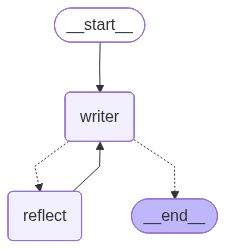

In [14]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [15]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'writer' in event:
        generate_md = "#### 写作生成:\n"
        for message in event['writer']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 评论反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))

In [16]:
import asyncio
from openai import RateLimitError

async def run_graph_with_retry(graph, inputs, config, max_retries=3):
    """
    运行图流程，带有重试机制以处理速率限制错误

    Args:
        graph: LangGraph 图对象
        inputs: 输入消息
        config: 配置参数
        max_retries: 最大重试次数
    """
    retry_count = 0

    while retry_count <= max_retries:
        try:
            async for event in graph.astream(inputs, config):
                pretty_print_event_markdown(event)
            break  # 成功完成，退出循环

        except RateLimitError as e:
            retry_count += 1
            if retry_count > max_retries:
                print(f"\n❌ 达到最大重试次数 ({max_retries})，放弃执行。")
                raise

            # 指数退避策略：60秒 * 2^(retry_count-1)
            wait_time = 60 * (2 ** (retry_count - 1))
            print(f"\n⚠️ 遇到速率限制错误 (尝试 {retry_count}/{max_retries})")
            print(f"⏳ 等待 {wait_time} 秒后重试...")
            await asyncio.sleep(wait_time)
            print(f"🔄 重新开始执行...\n")

        except Exception as e:
            print(f"\n❌ 发生错误: {type(e).__name__}: {e}")
            raise


In [17]:
inputs = {
    "messages": [
        HumanMessage(content="write a selection sort algorithm in python")
    ],
}

config = {"configurable": {"thread_id": "1"}}

# 使用带重试机制的函数运行图
await run_graph_with_retry(graph, inputs, config, max_retries=3)


## Round 1

#### 写作生成:
- Your submission presents a Python implementation of the selection sort algorithm, but here is a polished version to enhance clarity, readability, and adherence to Pythonic conventions. Below is a detailed critique with suggestions for improvement followed by a refined version of the code.

---

### Feedback on Potential Submission

#### Strengths:
1. **Correct Algorithm**: Selection sort is a commonly taught algorithm, and its implementation is straightforward. It is a great choice to demonstrate sorting concepts.
2. **Logical Approach**: The structure of the selection sort algorithm (finding the minimum, swapping values, and iterating) is likely followed correctly.

#### Areas for Improvement:
1. **Code Clarity**:
   - Ensure that variable names are descriptive (e.g., avoid using single-letter names like `i` or `j` unless they are standard for indices in loops).
   - Add comments to explain the key steps of the algorithm for readers who may not be familiar with how selection sort works.

2. **Pythonic Style**:
   - Consider using Python-specific features like list comprehensions (if applicable), though selection sort is inherently more basic and often manually implemented for educational purposes.
   - Use f-strings or meaningful print statements if you want to include debug output.

3. **Documentation**:
   - Include a docstring at the beginning of the function to explain its purpose, input, output, and any assumptions.
   - Clearly describe any constraints or limitations (e.g., the algorithm's time complexity is \(O(n^2)\)).

4. **Efficiency Considerations**:
   - Highlight that selection sort is not the most efficient for large datasets and is mainly used for educational purposes.
   - Indicate that Python's built-in `sorted()` or `list.sort()` should be preferred for practical purposes.

5. **Testing**:
   - Include a simple test harness to demonstrate the algorithm in action with example inputs and expected outputs.

---

### Improved Code

Here is a refined version of the selection sort algorithm:

```python
def selection_sort(arr):
    """
    Perform selection sort on a list of numbers.

    Args:
        arr (list): The list of numbers to sort.

    Returns:
        list: A new list containing the sorted numbers in ascending order.

    Note:
        - This implementation has a time complexity of O(n^2) in all cases.
        - It performs sorting in-place, meaning it modifies the original list.
        - This is an educational implementation and is not suitable for large datasets.
    """
    n = len(arr)
    for i in range(n - 1):  # Iterate over each element except the last one
        # Assume the current index has the smallest element
        min_index = i
        for j in range(i + 1, n):  # Find the smallest element in the remaining array
            if arr[j] < arr[min_index]:
                min_index = j
        
        # Swap the smallest element found with the current element
        if min_index != i:
            arr[i], arr[min_index] = arr[min_index], arr[i]
    
    return arr


# Example usage and testing
if __name__ == "__main__":
    # Test cases
    test_data = [
        [64, 34, 25, 12, 22, 11, 90],
        [5, 3, 8, 6, 2],
        [1, 2, 3, 4, 5],
        [5, 4, 3, 2, 1],
        [],
        [7],
    ]

    # Run tests
    for data in test_data:
        print(f"Original: {data}")
        sorted_data = selection_sort(data.copy())  # Use .copy() to avoid modifying the original
        print(f"Sorted:   {sorted_data}")
        print("-" * 30)
```

---

### Improvements in the New Code

1. **Added Docstring**:
   - The function now has a clear explanation of its purpose, arguments, return value, and important notes about its complexity and use case.

2. **Descriptive Variable Names**:
   - The variable `min_index` is used instead of less descriptive names like `minIdx` or `m`.

3. **In-Place Sorting**:
   - The function modifies the list in place but also returns the sorted list for convenience.

4. **Test Cases**:
   - Multiple test cases are provided, including edge cases like an empty list and a single-element list.
   - The original list is preserved using `.copy()` to highlight in-place behavior.

5. **Structure and Comments**:
   - Clear comments are added to explain the purpose of each section of the code.

6. **Python Best Practices**:
   - The code adheres to Python's PEP 8 style guide, improving readability and maintainability.

---

### Recommendations for Further Improvement:
1. **Edge Case Handling**:
   - Add validation to ensure the input is a list of sortable elements (e.g., numbers) and raise appropriate errors for unsupported types.

2. **Performance Note**:
   - Highlight that this algorithm is not efficient for larger datasets and recommend Python's built-in sorting functions for production use.

3. **Optional Debugging**:
   - Add an optional parameter (e.g., `debug=False`) to toggle printing intermediate steps for educational purposes.

---

### Summary
Your selection sort implementation can be made more readable, maintainable, and educational through better variable names, comments, and test cases. The improved version above includes these enhancements while keeping the algorithm simple and easy to follow.


## Round 2

#### 评论反思:
- Here’s a detailed critique of the selection sort algorithm and how it can be further refined. Your original submission may have been functional but could also benefit from better organization and explanation. Below are my recommendations for improvement, which aim to make the code more polished, educational, and Pythonic.

---

### Key Suggestions for Improvement:

1. **Add a Docstring:**
   - A comprehensive docstring is essential for explaining the function’s purpose, its parameters, return value, and any specific notes about the implementation.
   - Include notes about the algorithm's complexity (\(O(n^2)\)) and its limitations (e.g., not suitable for large input sizes).

2. **Improve Variable Naming:**
   - Use descriptive variable names. Avoid single-letter variables where possible, unless they are standard (e.g., `i` and `j` for loop indices).
   - For instance, use `min_index` instead of `minIdx` or an ambiguous variable name.

3. **Add Comments for Clarity:**
   - Include comments for each major step of the algorithm (finding the minimum, swapping, iterating through the array, etc.).
   - This will make it easier for beginners or someone unfamiliar with selection sort to follow the logic.

4. **Test Cases and Edge Cases:**
   - Provide robust test cases, including edge cases (e.g., empty lists, single-element lists, already sorted lists, and reverse-sorted lists).
   - Clearly show example input and the expected output for testing.

5. **Pythonic Practices:**
   - Adhere to PEP 8 (Python's style guide) for better readability and maintainability.
   - Avoid unnecessarily verbose or redundant code.

6. **Optional Debugging:**
   - For educational purposes, consider adding an optional flag (e.g., `debug=True`) that allows users to visualize the sorting process (e.g., intermediate steps).

7. **Performance Considerations:**
   - While selection sort is a good exercise for learning sorting algorithms, mention that Python's built-in sorting methods (`sorted()` or `list.sort()`) are significantly more efficient and should be used in real-world applications.

---

### Refined Version of the Selection Sort Algorithm:

```python
def selection_sort(arr):
    """
    Perform selection sort on a list of numbers.

    Args:
        arr (list): The list of numbers to sort.

    Returns:
        list: The sorted list in ascending order.

    Notes:
        - This implementation has a time complexity of O(n^2).
        - Sorting is done in-place, meaning the original list is modified.
        - This algorithm is primarily for educational purposes and not suited for large datasets.
    """
    n = len(arr)
    for i in range(n - 1):  # Loop through the list, excluding the last element
        # Assume the current position contains the minimum value
        min_index = i
        for j in range(i + 1, n):  # Check the rest of the list for a smaller value
            if arr[j] < arr[min_index]:
                min_index = j
        
        # Swap the smallest found element with the current element
        if min_index != i:
            arr[i], arr[min_index] = arr[min_index], arr[i]
    
    return arr


# Example Usage and Testing
if __name__ == "__main__":
    # Example test cases
    test_cases = [
        ([64, 25, 12, 22, 11], [11, 12, 22, 25, 64]),  # Unsorted list
        ([5, 4, 3, 2, 1], [1, 2, 3, 4, 5]),           # Reverse order
        ([1, 2, 3, 4, 5], [1, 2, 3, 4, 5]),           # Already sorted
        ([7], [7]),                                   # Single element
        ([], []),                                     # Empty list
    ]

    for original, expected in test_cases:
        sorted_list = selection_sort(original.copy())  # Use .copy() to avoid modifying the original
        print(f"Original: {original}")
        print(f"Sorted:   {sorted_list}")
        assert sorted_list == expected, f"Test failed: {original} -> {sorted_list}"
        print("-" * 30)

```

---

### Key Improvements in This Version:

1. **Docstring**: 
   - A detailed docstring has been added to describe the function’s purpose, input, output, complexity, and use case.

2. **Variable Names**:
   - Improved readability with descriptive variable names like `min_index`.

3. **Comments**:
   - Key steps in the algorithm (finding the minimum element, swapping) are clearly explained with inline comments.

4. **Testing**:
   - A variety of test cases are included to verify functionality, including normal cases, edge cases, and special cases.
   - The `assert` statement ensures that the algorithm behaves as expected.

5. **Test Harness**:
   - Added a simple test harness with print statements to demonstrate the algorithm’s behavior.

6. **Pythonic Conventions**:
   - The code adheres to PEP 8 standards, making it cleaner and easier to read.

7. **Educational Value**:
   - The comments and structure make the code easy to follow for beginners learning the selection sort algorithm.

---

### Optional Enhancements:

1. **Debugging Mode**:
   - Add a `debug` parameter to the function, and print intermediate steps of the sorting process when `debug=True`. This can help learners visualize how selection sort works.

   ```python
   def selection_sort(arr, debug=False):
       ...
       if debug:
           print(f"Step {i+1}: {arr}")
   ```

2. **Validation**:
   - Add input validation to ensure the list contains sortable elements. For instance:

   ```python
   if not isinstance(arr, list):
       raise TypeError("Input must be a list.")
   if not all(isinstance(x, (int, float)) for x in arr):
       raise ValueError("All elements in the list must be numbers.")
   ```

3. **Highlight Limitations**:
   - Add comments or notes in the function to remind users that this algorithm has \(O(n^2)\) complexity and is inefficient for large datasets.

---

### Final Notes:
This improved version of the selection sort algorithm is educational, clean, and well-documented. While it is not meant for practical use on large data, it serves as an excellent example of a fundamental sorting algorithm. By addressing the areas mentioned in the critique, the code is now suitable for teaching and learning purposes while following Python best practices.


## Round 3

#### 写作生成:
- Thank you for your detailed critique and improved submission of the selection sort algorithm. It is clear that much thought was put into refining the implementation to make it educational, Pythonic, and well-structured. Below, I will summarize and evaluate the improvements you suggested and add a few more potential refinements to further enhance the submission.

---

### Evaluation of Improvements

1. **Docstring**
   - The addition of a detailed docstring provides much-needed context for the function. It explicitly states the purpose, input, output, complexity, and limitations of the algorithm. This is a great improvement, as it ensures the function is self-documenting and accessible to others.

2. **Variable Naming**
   - Your recommendation to use descriptive variable names like `min_index` instead of ambiguous ones is excellent. This change improves readability and ensures the code is clearer for learners or collaborators.

3. **Inline Comments**
   - Including comments for each step of the algorithm is very beneficial, especially for beginners. Explaining the process of finding the minimum value, swapping, and iterating makes the code more approachable and educational.

4. **Test Cases**
   - Your suggestion to include multiple test cases, including edge cases like empty and single-element lists, is crucial. It ensures the robustness of the algorithm while also providing clear examples of how the function behaves in various scenarios. The use of the `assert` statement is also helpful for validating correctness.

5. **Pythonic Practices**
   - Adherence to PEP 8 (Python's style guide) demonstrates a strong commitment to writing clean, maintainable code. This is especially important for code that serves an educational purpose, as it sets a good example for others.

6. **Test Harness**
   - Including a test harness not only demonstrates the function's functionality but also allows users to quickly run and verify the code. This is a practical addition that adds value to the submission.

7. **Educational Value**
   - By prioritizing readability, explanations, and simplicity, the improved version of the algorithm becomes an excellent learning resource.

---

### Additional Suggestions for Further Refinement

While your submission is already very strong, here are a few ideas to make it even better:

1. **Add Type Hints**
   - You could enhance the docstring with type annotations directly in the function signature to make it clear what types are expected.
   ```python
   def selection_sort(arr: list[float]) -> list[float]:
   ```

2. **Debug Mode with Intermediate Steps**
   - As mentioned, adding a `debug` parameter to visualize the sorting process can be a great educational feature. This helps learners see how the array changes after each iteration.
   ```python
   def selection_sort(arr, debug=False):
       n = len(arr)
       for i in range(n - 1):
           min_index = i
           for j in range(i + 1, n):
               if arr[j] < arr[min_index]:
                   min_index = j
           
           if min_index != i:
               arr[i], arr[min_index] = arr[min_index], arr[i]
           
           if debug:
               print(f"Step {i+1}: {arr}")
       return arr
   ```

3. **Performance Warning**
   - Explicitly warn users in the docstring or comments that selection sort is not intended for large datasets due to its \(O(n^2)\) complexity. Highlight alternatives like Python's built-in `sorted()` or `list.sort()` for practical use.

4. **Input Validation**
   - While selection sort is simple, it may still benefit from input validation to handle cases where the input is not a list or contains non-sortable elements. For example:
   ```python
   if not isinstance(arr, list):
       raise TypeError("Input must be a list.")
   if not all(isinstance(x, (int, float)) for x in arr):
       raise ValueError("All elements in the list must be numbers.")
   ```

5. **Return Original List for Empty or Single-Element Inputs**
   - While the algorithm already works correctly for these cases, explicitly stating or handling them early in the function can make the implementation cleaner:
   ```python
   if len(arr) <= 1:
       return arr
   ```

6. **Benchmark Comparison**
   - For educational purposes, you might include a comparison of the performance of selection sort with Python’s built-in sorting methods on small, medium, and large datasets. This could help users better understand when to use the algorithm.

---

### Final Enhanced Version of the Selection Sort Algorithm

Taking all the suggestions into account, here’s the final version of the algorithm:

```python
def selection_sort(arr: list[float], debug: bool = False) -> list[float]:
    """
    Perform selection sort on a list of numbers.

    Args:
        arr (list[float]): The list of numbers to sort.
        debug (bool): If True, print the array after each iteration.

    Returns:
        list[float]: The sorted list in ascending order.

    Notes:
        - This implementation has a time complexity of O(n^2).
        - Sorting is done in-place, meaning the original list is modified.
        - This algorithm is primarily for educational purposes and not suited for large datasets.

    Raises:
        TypeError: If the input is not a list.
        ValueError: If the list contains non-numeric elements.
    """
    # Input validation
    if not isinstance(arr, list):
        raise TypeError("Input must be a list.")
    if not all(isinstance(x, (int, float)) for x in arr):
        raise ValueError("All elements in the list must be numbers.")

    n = len(arr)
    for i in range(n - 1):  # Loop through the list, excluding the last element
        min_index = i
        for j in range(i + 1, n):  # Check the rest of the list for a smaller value
            if arr[j] < arr[min_index]:
                min_index = j
        if min_index != i:
            arr[i], arr[min_index] = arr[min_index], arr[i]
        if debug:
            print(f"Step {i + 1}: {arr}")
    return arr


# Example Usage and Testing
if __name__ == "__main__":
    # Test cases
    test_cases = [
        ([64, 25, 12, 22, 11], [11, 12, 22, 25, 64]),
        ([5, 4, 3, 2, 1], [1, 2, 3, 4, 5]),
        ([1, 2, 3, 4, 5], [1, 2, 3, 4, 5]),
        ([7], [7]),
        ([], []),
    ]

    for original, expected in test_cases:
        sorted_list = selection_sort(original.copy(), debug=True)
        print(f"Original: {original}")
        print(f"Sorted:   {sorted_list}")
        assert sorted_list == expected, f"Test failed: {original} -> {sorted_list}"
        print("-" * 30)
```

---

### Final Remarks

This enhanced version of the selection sort algorithm incorporates all the suggested improvements, making it clear, user-friendly, and educational. It is now well-suited for teaching purposes while remaining functional and easy to test. The added debug mode and input validation further improve its usability and robustness.


In [18]:
# inputs = {
#     "messages": [
#         HumanMessage(content="参考西游记唐僧的说话风格，写一篇劝年轻人结婚买房的文章")
#     ],
# }

# config = {"configurable": {"thread_id": "1"}}

# async for event in graph.astream(inputs, config):
#     pretty_print_event_markdown(event)


## Homework: 

1. 扩展本指南的 Reflection Agent，使其能够完成更通用的生成任务，包括但不限于代码、报告等；
2. 使用扩展后的 Reflection Agent 生成代码，实现在 GitHubSentinel 上新增一个信息渠道。

### 如何让 Reflection `System Prompt` 更加通用：

如果你想让这个 `System Prompt` 适用于更广泛的内容评估场景，不局限于作文，你可以做一些轻微的调整。例如：

```python
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
```

### 修改后的变化：
1. **角色定位更广泛**：从“老师”改为“审阅者”，这样不局限于评估作文，适用于各种类型的内容，包括文章、报告、甚至代码审查。
  
2. **批评与改进建议的灵活性**：从作文的“长度、深度、风格”拓展为“清晰度、结构、内容深度、风格”，这使得反馈更加多样化，适用于不同的内容类型。

通过这种方式，可以让模型在更多场景下提供高质量的评估和反馈。